# Hillstrom Email Marketing A/B Test

## Introduction

This project analyzes a real-world email marketing experiment from the Hillstrom MineThatData dataset.

The business question is:

> Should the company send marketing emails, and if yes, which campaign performs best?

The experiment has three groups:

1. **Mens E-Mail** — customers who received a men's merchandise email
2. **Womens E-Mail** — customers who received a women's merchandise email
3. **No E-Mail** — control group that received no email

We will measure impact using:

- Visit rate
- Conversion rate
- Average spend per customer
- Total revenue
- Incremental revenue lift
- Customer segment performance

This matters because A/B testing helps businesses avoid guessing and make revenue decisions with evidence.

In [1]:
# Core data tools
import pandas as pd
import numpy as np

# Statistical testing
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

Load data

In [2]:
# Load the local Hillstrom dataset
DATA_PATH = "../data/raw/hillstrom_email_marketing.csv"

df = pd.read_csv(DATA_PATH)

# Preview the first rows
df.head()

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.4400,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0000
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000
2,7,2) $100 - $200,180.6500,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0000
3,9,5) $500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000
4,2,1) $0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000


In [3]:
# Check number of rows and columns
df.shape

(64000, 12)

Inspect columns

In [4]:
# Standardize column names for easier coding
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Confirm cleaned columns
df.columns.tolist()

['recency',
 'history_segment',
 'history',
 'mens',
 'womens',
 'zip_code',
 'newbie',
 'channel',
 'segment',
 'visit',
 'conversion',
 'spend']

Missing Values

In [5]:
df.isna().sum()

recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

## Data Understanding

Each row represents one customer.

Important columns:

- `segment`: experiment group
- `visit`: whether the customer visited the website
- `conversion`: whether the customer purchased
- `spend`: amount spent by the customer
- `history`: past customer spending history
- `channel`: customer acquisition channel
- `zip_code`: customer location type
- `newbie`: whether the customer is new

The main outcome variables are:

1. `visit`
2. `conversion`
3. `spend`

In [6]:
# Count customers in each experiment group
df["segment"].value_counts()

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

In [7]:
# Check percentage split across experiment groups
df["segment"].value_counts(normalize=True).mul(100).round(2)

segment
Womens E-Mail   33.4200
Mens E-Mail     33.2900
No E-Mail       33.2900
Name: proportion, dtype: float64

## Experiment Design Check

Before measuring results, we need to check whether the groups are reasonably balanced.

A good A/B test should have treatment and control groups that are similar before the treatment happens.

If the groups are similar, then differences in outcomes are more likely caused by the email campaign rather than pre-existing customer differences.

Balance check

In [8]:
# Compare customer characteristics by experiment group
balance_check = (
    df.groupby("segment")
    .agg(
        customers=("segment", "size"),
        avg_recency=("recency", "mean"),
        avg_history=("history", "mean"),
        mens_rate=("mens", "mean"),
        womens_rate=("womens", "mean"),
        newbie_rate=("newbie", "mean")
    )
    .reset_index()
)

balance_check

,segment,customers,avg_recency,avg_history,mens_rate,womens_rate,newbie_rate
0,Mens E-Mail,21307,5.7736,242.8359,0.5509,0.5514,0.5015
1,No E-Mail,21306,5.7497,240.8827,0.5532,0.5476,0.5020
2,Womens E-Mail,21387,5.7678,242.5366,0.5489,0.5501,0.5032


## Business Metrics by Experiment Group

Now we compare the business outcomes across the three groups.

We care about:

- Visit rate: Did the email make customers visit?
- Conversion rate: Did the email make customers buy?
- Total spend: How much revenue came from each group?
- Average spend per customer: How much each assigned customer was worth?
- Average spend per buyer: How much buyers spent after purchasing?

### Main experiment summary

In [9]:
# Summarize business outcomes by experiment group
experiment_summary = (
    df.groupby("segment")
    .agg(
        customers=("segment", "size"),
        visits=("visit", "sum"),
        conversions=("conversion", "sum"),
        visit_rate=("visit", "mean"),
        conversion_rate=("conversion", "mean"),
        total_spend=("spend", "sum"),
        avg_spend_per_customer=("spend", "mean"),
        avg_spend_per_buyer=("spend", lambda x: x[x > 0].mean())
    )
    .reset_index()
)

experiment_summary

,segment,customers,visits,conversions,visit_rate,conversion_rate,total_spend,avg_spend_per_customer,avg_spend_per_buyer
0,Mens E-Mail,21307,3894,267,0.1828,0.0125,"30,311.6900",1.4226,113.5269
1,No E-Mail,21306,2262,122,0.1062,0.0057,"13,908.3300",0.6528,114.0027
2,Womens E-Mail,21387,3238,189,0.1514,0.0088,"23,038.1100",1.0772,121.8948


<Axes: xlabel='conversion', ylabel='count'>

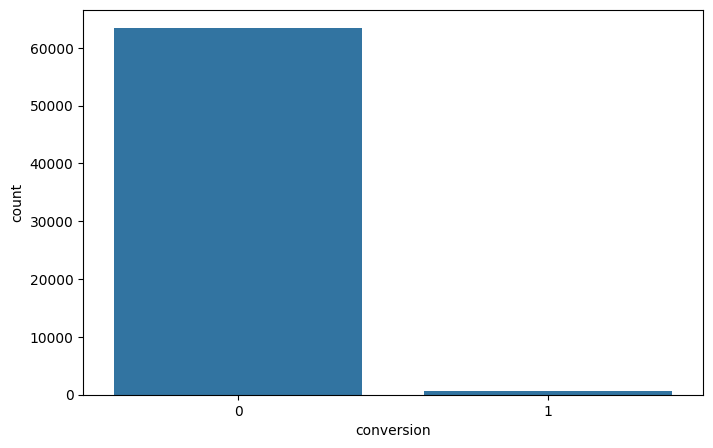

In [10]:
# Visualize average spend per customer by experiment group
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="conversion")

Cleaner display table

In [11]:
# Create a readable version of the summary table
summary_display = experiment_summary.copy()

summary_display["visit_rate"] = (summary_display["visit_rate"] * 100).round(2)
summary_display["conversion_rate"] = (summary_display["conversion_rate"] * 100).round(2)
summary_display["total_spend"] = summary_display["total_spend"].round(2)
summary_display["avg_spend_per_customer"] = summary_display["avg_spend_per_customer"].round(2)
summary_display["avg_spend_per_buyer"] = summary_display["avg_spend_per_buyer"].round(2)

summary_display

,segment,customers,visits,conversions,visit_rate,conversion_rate,total_spend,avg_spend_per_customer,avg_spend_per_buyer
0,Mens E-Mail,21307,3894,267,18.2800,1.2500,"30,311.6900",1.4200,113.5300
1,No E-Mail,21306,2262,122,10.6200,0.5700,"13,908.3300",0.6500,114.0000
2,Womens E-Mail,21387,3238,189,15.1400,0.8800,"23,038.1100",1.0800,121.8900


Visit rate chart

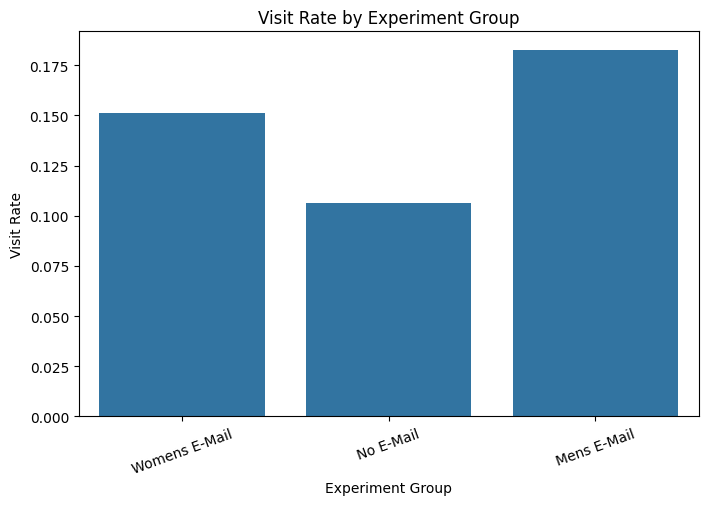

In [12]:
# Visualize visit rate by experiment group
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="segment", y="visit", estimator=np.mean, errorbar=None)
plt.title("Visit Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Visit Rate")
plt.xticks(rotation=20)
plt.show()

Conversion rate chart

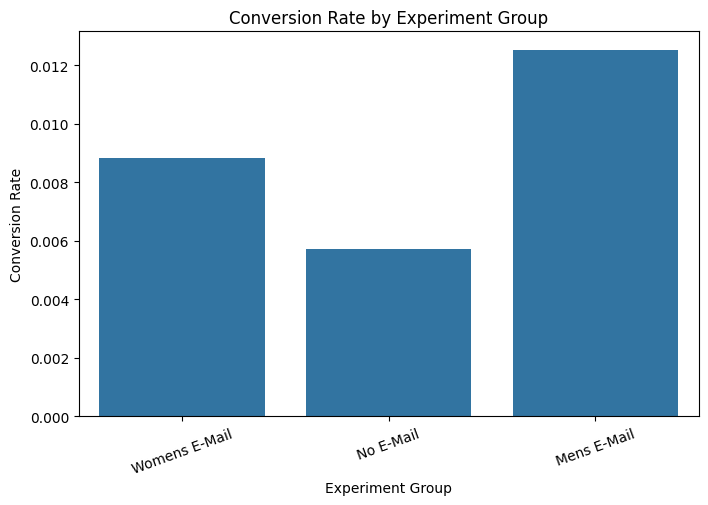

In [13]:
# Visualize conversion rate by experiment group
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="segment", y="conversion", estimator=np.mean, errorbar=None)
plt.title("Conversion Rate by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=20)
plt.show()

Average spend chart

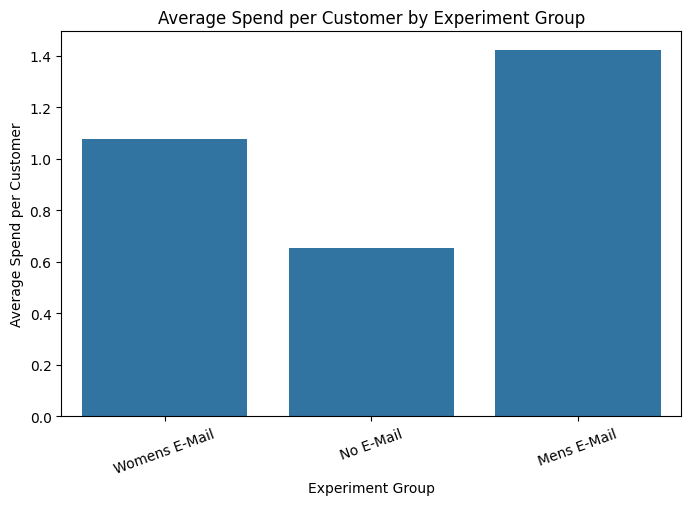

In [14]:
# Visualize average spend per customer by experiment group
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="segment", y="spend", estimator=np.mean, errorbar=None)
plt.title("Average Spend per Customer by Experiment Group")
plt.xlabel("Experiment Group")
plt.ylabel("Average Spend per Customer")
plt.xticks(rotation=20)
plt.show()

## Hypothesis Test 1: Mens Email vs No Email

We test whether the men's email campaign improved conversion compared with the control group.

### Hypotheses

**Null hypothesis:**  
The conversion rate for Mens E-Mail is equal to the conversion rate for No E-Mail.

**Alternative hypothesis:**  
The conversion rate for Mens E-Mail is different from the conversion rate for No E-Mail.

We use a two-proportion z-test because conversion is a binary outcome:

- 1 = customer converted
- 0 = customer did not convert

In [15]:
# create treatment and control groups
mens_email = df[df["segment"] == "Mens E-Mail"]
control = df[df["segment"]== "No E-Mail"]

# Count Conversions
mens_conversions = mens_email["conversion"].sum()
control_conversions = control["conversion"].sum()

In [16]:
# count customers
mens_n = mens_email.shape[0]
control_n = control.shape[0]

In [17]:
# run two proportion z-test
count = np.array([mens_conversions, control_conversions])
nobs = np.array([mens_n, control_n])

In [18]:
nobs

array([21307, 21306])

In [19]:
z_stat_mens, p_value_mens = proportions_ztest(count, nobs)

In [20]:
z_stat_mens

np.float64(7.385114410925771)

In [21]:
p_value_mens

np.float64(1.5232235005955427e-13)

In [22]:
print(f"Mens Email conversion rate: {mens_conversions / mens_n:.4%}")
print(f"No Email conversion rate: {control_conversions / control_n:.4%}")
print(f"Z-statistic: {z_stat_mens:.4f}")
print(f"P-value: {p_value_mens:.6f}")

Mens Email conversion rate: 1.2531%
No Email conversion rate: 0.5726%
Z-statistic: 7.3851
P-value: 0.000000


#### Mens E-Mail Interpretation

In [23]:
# Interpret the p-value
alpha = 0.05

if p_value_mens < alpha:
    print("Result: Statistically significant.")
    print("Interpretation: Mens E-Mail conversion is meaningfully different from No E-Mail.")
else:
    print("Result: Not statistically significant.")
    print("Interpretation: We do not have enough evidence that Mens E-Mail changed conversion.")

Result: Statistically significant.
Interpretation: Mens E-Mail conversion is meaningfully different from No E-Mail.


## Hypothesis Test 2: Womens Email vs No Email

Now we test whether the women's email campaign improved conversion compared with the control group.

#### womens email z-test

In [24]:
# create treatment group
womens_email = df[df["segment"]=="Womens E-Mail"]

In [25]:
# count conversions
womens_conversions = womens_email["conversion"].sum()

# count customers
womens_n = womens_email.shape[0]

In [26]:
womens_conversions

np.int64(189)

In [27]:
womens_n

21387

In [28]:
# run two-proportion z-test
count_w = np.array([womens_conversions, control_conversions])
nobs_w = np.array([womens_n, control_n])

In [29]:
z_stat_womens, p_value_womens = proportions_ztest(count_w, nobs_w)

In [30]:
z_stat_womens

np.float64(3.77956095835785)

In [31]:
p_value_womens

np.float64(0.00015710512910668448)

In [32]:
print(f"Womens Email conversion rate: {womens_conversions / womens_n:.4%}")
print(f"No Email conversion rate: {control_conversions / control_n:.4%}")
print(f"Z-statistic: {z_stat_womens:.4f}")
print(f"P-value: {p_value_womens:.6f}")

Womens Email conversion rate: 0.8837%
No Email conversion rate: 0.5726%
Z-statistic: 3.7796
P-value: 0.000157


#### Womens email interpretation

In [33]:
# Interpret the p-value
if p_value_womens < alpha:
    print("Result: Statistically significant.")
    print("Interpretation: Womens E-Mail conversion is meaningfully different from No E-Mail.")
else:
    print("Result: Not statistically significant.")
    print("Interpretation: We do not have enough evidence that Womens E-Mail changed conversion.")

Result: Statistically significant.
Interpretation: Womens E-Mail conversion is meaningfully different from No E-Mail.


## Revenue Lift Analysis

Statistical significance is useful, but business decisions also need financial impact.

Now we estimate incremental revenue by comparing each group against the No E-Mail control group.

The formula is:

> Incremental spend per customer = Treatment average spend per customer - Control average spend per customer

Then:

> Estimated incremental revenue = Incremental spend per customer × number of customers in the treatment group

In [34]:
control

,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000
14,4,3) $200 - $350,241.4200,0,1,Rural,1,Multichannel,No E-Mail,0,0,0.0000
15,3,1) $0 - $100,58.1300,1,0,Urban,1,Web,No E-Mail,1,0,0.0000
20,9,1) $0 - $100,29.9900,0,1,Surburban,1,Phone,No E-Mail,0,0,0.0000
23,2,1) $0 - $100,29.9900,0,1,Urban,1,Phone,No E-Mail,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
63980,3,4) $350 - $500,487.1000,0,1,Surburban,1,Phone,No E-Mail,0,0,0.0000
63981,4,2) $100 - $200,125.5300,0,1,Rural,1,Phone,No E-Mail,0,0,0.0000
63983,2,1) $0 - $100,83.0300,0,1,Urban,0,Phone,No E-Mail,0,0,0.0000
63987,1,1) $0 - $100,79.7000,1,0,Surburban,1,Web,No E-Mail,0,0,0.0000


In [35]:
# Get control group average spend per customer
control_spend_per_customer = control["spend"].mean()

In [36]:
experiment_summary

,segment,customers,visits,conversions,visit_rate,conversion_rate,total_spend,avg_spend_per_customer,avg_spend_per_buyer
0,Mens E-Mail,21307,3894,267,0.1828,0.0125,"30,311.6900",1.4226,113.5269
1,No E-Mail,21306,2262,122,0.1062,0.0057,"13,908.3300",0.6528,114.0027
2,Womens E-Mail,21387,3238,189,0.1514,0.0088,"23,038.1100",1.0772,121.8948


In [37]:
# Calculate revenue lift against control
revenue_lift = experiment_summary.copy()

revenue_lift["control_spend_per_customer"] = control_spend_per_customer

In [38]:
revenue_lift

,segment,customers,visits,conversions,visit_rate,conversion_rate,total_spend,avg_spend_per_customer,avg_spend_per_buyer,control_spend_per_customer
0,Mens E-Mail,21307,3894,267,0.1828,0.0125,"30,311.6900",1.4226,113.5269,0.6528
1,No E-Mail,21306,2262,122,0.1062,0.0057,"13,908.3300",0.6528,114.0027,0.6528
2,Womens E-Mail,21387,3238,189,0.1514,0.0088,"23,038.1100",1.0772,121.8948,0.6528


In [39]:
revenue_lift["incremental_spend_per_customer"] = (
    revenue_lift["avg_spend_per_customer"] 
    - revenue_lift["control_spend_per_customer"]
)

In [40]:
revenue_lift["estimated_incremental_revenue"] = (
    revenue_lift["incremental_spend_per_customer"] 
    * revenue_lift["customers"]
)

In [41]:
revenue_lift

,segment,customers,visits,conversions,visit_rate,conversion_rate,total_spend,avg_spend_per_customer,avg_spend_per_buyer,control_spend_per_customer,incremental_spend_per_customer,estimated_incremental_revenue
0,Mens E-Mail,21307,3894,267,0.1828,0.0125,"30,311.6900",1.4226,113.5269,0.6528,0.7698,"16,402.7072"
1,No E-Mail,21306,2262,122,0.1062,0.0057,"13,908.3300",0.6528,114.0027,0.6528,0.0000,0.0000
2,Womens E-Mail,21387,3238,189,0.1514,0.0088,"23,038.1100",1.0772,121.8948,0.6528,0.4244,"9,076.9041"


In [42]:
revenue_lift_display = revenue_lift[
    [
        "segment",
        "customers",
        "avg_spend_per_customer",
        "control_spend_per_customer",
        "incremental_spend_per_customer",
        "estimated_incremental_revenue"
    ]
].copy()

revenue_lift_display.round(2)

,segment,customers,avg_spend_per_customer,control_spend_per_customer,incremental_spend_per_customer,estimated_incremental_revenue
0,Mens E-Mail,21307,1.4200,0.6500,0.7700,"16,402.7100"
1,No E-Mail,21306,0.6500,0.6500,0.0000,0.0000
2,Womens E-Mail,21387,1.0800,0.6500,0.4200,"9,076.9000"


Revenue lift chart

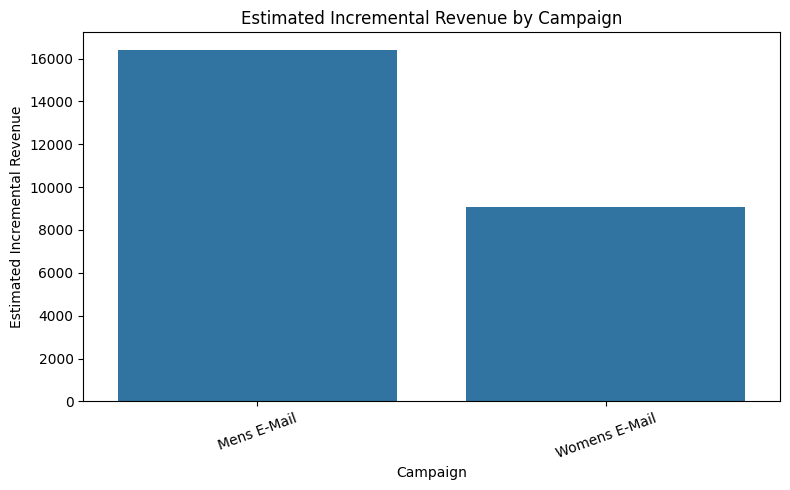

In [51]:
# Exclude control group for clearer lift comparison
lift_chart = revenue_lift[revenue_lift["segment"] != "No E-Mail"]

plt.figure(figsize=(8, 5))
sns.barplot(
    data=lift_chart,
    x="segment",
    y="estimated_incremental_revenue",
    errorbar=None
)
plt.title("Estimated Incremental Revenue by Campaign")
plt.xlabel("Campaign")
plt.ylabel("Estimated Incremental Revenue")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../reports/figures/incremental_revenue_by_campaign.png", dpi=300)
plt.show()

#### Chart Summary: Estimated Incremental Revenue by Campaign

This chart compares the estimated incremental revenue produced by each email campaign relative to the No E-Mail control group.

The **Mens E-Mail campaign clearly produced the strongest business impact**, generating approximately **$16.4K in estimated incremental revenue**. The **Womens E-Mail campaign also produced positive incremental revenue**, but at a lower level of roughly **$9.1K**.

This means both email campaigns created additional business value compared with not sending an email, but the Mens E-Mail campaign was more profitable overall.

From a business decision perspective, this chart suggests that the company should prioritize the Mens E-Mail campaign if the goal is to maximize short-term revenue lift. However, the Womens E-Mail campaign should not be ignored because it still produced positive incremental value.

The key takeaway is:

> Sending email is better than sending no email, but the Mens E-Mail campaign generated the highest revenue lift.

## Segment Analysis

A campaign may not work equally well for every customer.

Now we check performance by customer channel.

This helps answer:

> Which customer groups respond best to email?

In [44]:
# Analyze performance by customer channel and experiment group
channel_summary = (
    df.groupby(["channel", "segment"])
    .agg(
        customers=("segment", "size"),
        conversion_rate=("conversion", "mean"),
        avg_spend_per_customer=("spend", "mean"),
        total_spend=("spend", "sum")
    )
    .reset_index()
)

channel_summary

,channel,segment,customers,conversion_rate,avg_spend_per_customer,total_spend
0,Multichannel,Mens E-Mail,2577,0.0171,1.8249,"4,702.6900"
1,Multichannel,No E-Mail,2606,0.0069,0.6157,"1,604.6200"
2,Multichannel,Womens E-Mail,2579,0.0140,1.7733,"4,573.2800"
3,Phone,Mens E-Mail,9240,0.0108,1.2085,"11,166.7900"
4,Phone,No E-Mail,9327,0.0054,0.6445,"6,010.8100"
5,Phone,Womens E-Mail,9454,0.0071,0.8769,"8,290.4600"
6,Web,Mens E-Mail,9490,0.0130,1.5218,"14,442.2100"
7,Web,No E-Mail,9373,0.0058,0.6714,"6,292.9000"
8,Web,Womens E-Mail,9354,0.0092,1.0877,"10,174.3700"


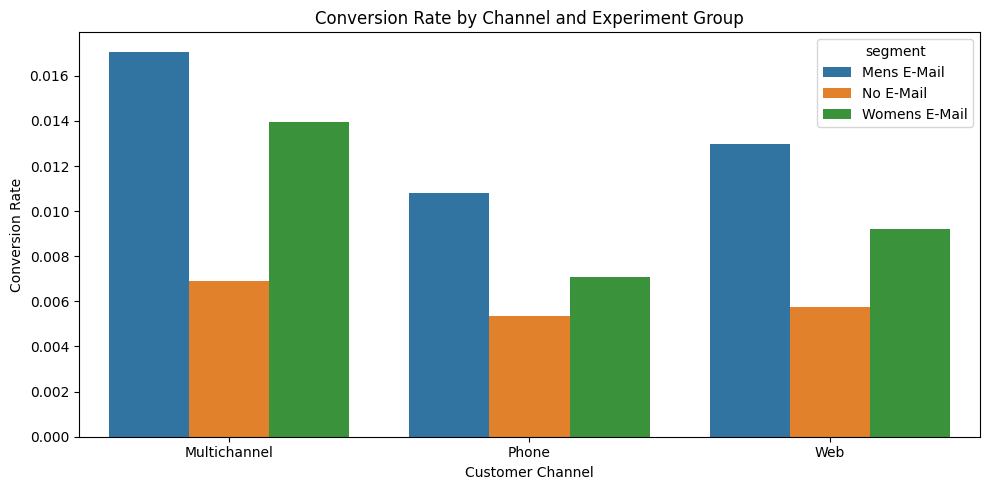

In [52]:
# Visualize conversion rate by channel and experiment group
plt.figure(figsize=(10, 5))
sns.barplot(
    data=channel_summary,
    x="channel",
    y="conversion_rate",
    hue="segment",
    errorbar=None
)
plt.title("Conversion Rate by Channel and Experiment Group")
plt.xlabel("Customer Channel")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.savefig("../reports/figures/conversion_rate_by_channel.png", dpi=300)
plt.show()

#### Chart Summary: Conversion Rate by Channel and Experiment Group

This chart shows how conversion rates differ across customer channels: **Multichannel**, **Phone**, and **Web**.

Across all three channels, the **Mens E-Mail campaign has the highest conversion rate**. This means customers who received the Mens E-Mail were more likely to purchase than customers in the Womens E-Mail or No E-Mail groups.

The **Multichannel group shows the strongest conversion performance overall**. Mens E-Mail customers in the Multichannel segment converted at the highest rate, followed by Womens E-Mail customers. This suggests that customers who already interact with the company through multiple channels are more responsive to email marketing.

The **Phone channel has the lowest conversion rates overall**, but Mens E-Mail still performs better than the control group. This means the campaign still helps, but the opportunity may be smaller compared with Multichannel or Web customers.

The **Web channel also shows a clear lift**, especially for Mens E-Mail. This tells us that digital-first customers respond well to email campaigns.

The key takeaway is:

> Email marketing works across all channels, but it performs best for Multichannel customers, with Mens E-Mail producing the strongest conversion lift.

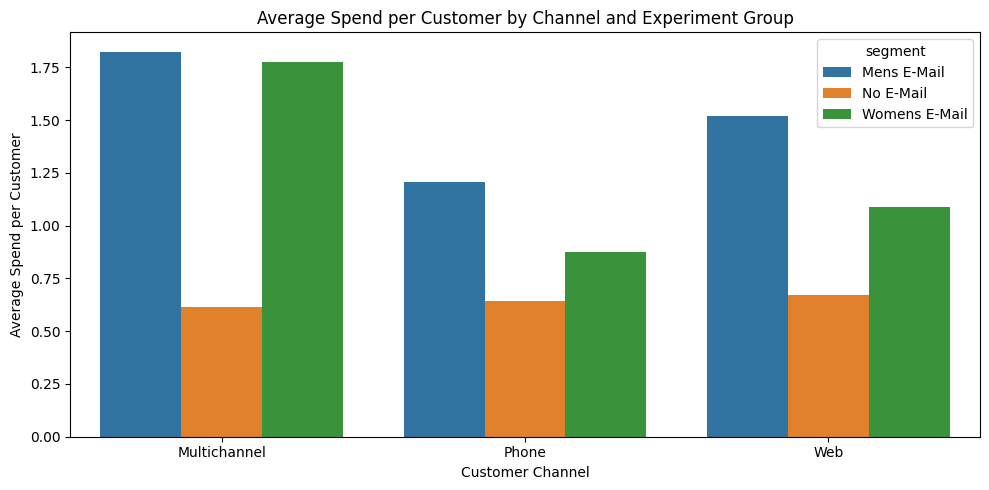

In [53]:
# Visualize average spend per customer by channel and experiment group
plt.figure(figsize=(10, 5))
sns.barplot(
    data=channel_summary,
    x="channel",
    y="avg_spend_per_customer",
    hue="segment",
    errorbar=None
)
plt.title("Average Spend per Customer by Channel and Experiment Group")
plt.xlabel("Customer Channel")
plt.ylabel("Average Spend per Customer")
plt.tight_layout()
plt.savefig("../reports/figures/average_spend_by_channel.png", dpi=300)
plt.show()

#### Chart Summary: Average Spend per Customer by Channel and Experiment Group

This chart compares average customer spend across channel and experiment group.

The **Mens E-Mail campaign produces the highest average spend per customer in every channel**, which supports the earlier revenue lift result. This means Mens E-Mail is not only increasing conversions, but also producing stronger revenue per assigned customer.

The **Multichannel segment has the highest spend overall**. Mens E-Mail and Womens E-Mail both perform strongly among Multichannel customers, while the No E-Mail group spends much less. This suggests that Multichannel customers are highly valuable and especially responsive to email campaigns.

The **Phone channel has lower average spend than Multichannel and Web**, but the Mens E-Mail group still outperforms both Womens E-Mail and No E-Mail. This shows the campaign still creates value even in weaker channels.

The **Web channel shows strong performance for Mens E-Mail**, with average spend clearly above Womens E-Mail and No E-Mail. This suggests Web customers may be a strong target for email-driven revenue campaigns.

The key takeaway is:

> Mens E-Mail creates the strongest spend lift across every channel, while Multichannel customers appear to be the most valuable audience segment.

Zip code analysis

In [47]:
# Analyze performance by zip code type and experiment group

zip_summary = (
    df.groupby(["zip_code", "segment"])
    .agg(
        customers=("segment", "size"),
        conversion_rate=("conversion", "mean"),
        avg_spend_per_customer=("spend", "mean"),
        total_spend=("spend", "sum")
    )
    .reset_index()
)

zip_summary

,zip_code,segment,customers,conversion_rate,avg_spend_per_customer,total_spend
0,Rural,Mens E-Mail,3243,0.0136,1.5226,"4,937.9100"
1,Rural,No E-Mail,3139,0.0083,0.7671,"2,408.0400"
2,Rural,Womens E-Mail,3181,0.0116,1.2820,"4,077.9700"
3,Surburban,Mens E-Mail,9501,0.0124,1.4733,"13,997.7300"
4,Surburban,No E-Mail,9625,0.0050,0.6694,"6,443.3800"
5,Surburban,Womens E-Mail,9650,0.0076,0.8466,"8,169.8200"
6,Urban,Mens E-Mail,8563,0.0123,1.3285,"11,376.0500"
7,Urban,No E-Mail,8542,0.0056,0.5920,"5,056.9100"
8,Urban,Womens E-Mail,8556,0.0092,1.2611,"10,790.3200"


Zip conversion chart

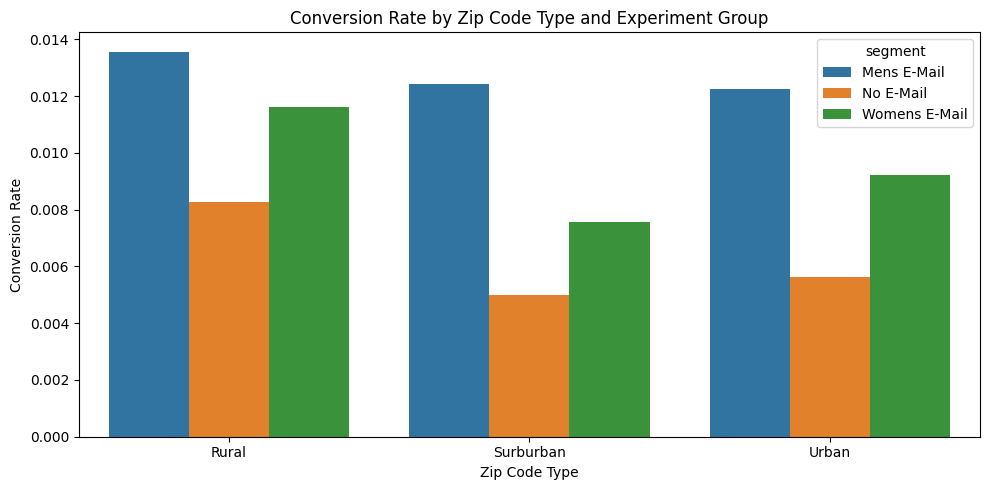

In [54]:
# visiualize conversion rate by zip code type and experiment group

plt.figure(figsize=(10, 5))
sns.barplot(
    data=zip_summary,
    x="zip_code",
    y="conversion_rate",
    hue="segment",
    errorbar=None
)
plt.title("Conversion Rate by Zip Code Type and Experiment Group")
plt.xlabel("Zip Code Type")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.savefig("../reports/figures/conversion_rate_by_zip_code.png", dpi=300)
plt.show()

#### Chart Summary: Conversion Rate by Zip Code Type and Experiment Group

This chart compares conversion rates across zip code types: **Rural**, **Suburban**, and **Urban**.

The **Mens E-Mail campaign has the highest conversion rate across all zip code types**. This confirms that the campaign performs consistently well across different geographic customer segments.

The **Rural segment has the highest conversion rate overall**, especially for Mens E-Mail and Womens E-Mail. This suggests rural customers may be more responsive to email marketing than suburban or urban customers.

The **Suburban segment shows a strong lift for Mens E-Mail**, but Womens E-Mail performs lower in this group compared with Rural customers. This may indicate that the Mens E-Mail campaign has broader appeal across suburban customers.

The **Urban segment also responds better to Mens E-Mail than Womens E-Mail or No E-Mail**, but the Womens E-Mail lift is smaller compared with Rural customers.

The key takeaway is:

> Mens E-Mail performs best across Rural, Suburban, and Urban customers, while Rural customers appear to be the most responsive geographic segment overall.

In [49]:
# Save cleaned dataset for future analysis or modeling
df.to_csv("../data/processed/hillstrom_cleaned.csv", index=False)

print("Cleaned data saved to ../data/processed/hillstrom_cleaned.csv")

Cleaned data saved to ../data/processed/hillstrom_cleaned.csv


In [50]:
# Find the campaign with the highest estimated incremental revenue
campaign_lift = revenue_lift[revenue_lift["segment"] != "No E-Mail"].copy()

best_campaign = campaign_lift.sort_values(
    "estimated_incremental_revenue", 
    ascending=False
).iloc[0]

print(f"Best campaign by estimated incremental revenue: {best_campaign['segment']}")
print(f"Estimated incremental revenue: ${best_campaign['estimated_incremental_revenue']:,.2f}")
print(f"Incremental spend per customer: ${best_campaign['incremental_spend_per_customer']:,.2f}")

Best campaign by estimated incremental revenue: Mens E-Mail
Estimated incremental revenue: $16,402.71
Incremental spend per customer: $0.77


In [55]:
# Create folder for saved figures
import os

os.makedirs("../reports/figures", exist_ok=True)

## Overall Segment Insight

The segment-level analysis shows that the Mens E-Mail campaign is the strongest campaign across revenue, conversion, customer channel, and zip code type.

The strongest customer opportunity appears to be:

> Multichannel customers receiving the Mens E-Mail campaign.

These customers show both high conversion rates and high average spend per customer, making them a valuable target for future campaigns.

The company should consider a more targeted email strategy instead of sending campaigns broadly to all customers. A smarter strategy would prioritize customers who are more likely to respond and spend, especially Multichannel and high-history customers.

This turns the project from a simple A/B test into a practical marketing decision system:

**Experiment result → customer segment insight → targeting recommendation → revenue lift**

# Conclusion

This project analyzed a real-world email marketing A/B test using the Hillstrom MineThatData dataset.

## What We Did

We used Python to:

1. Load and inspect the experiment dataset
2. Check treatment group sizes and balance
3. Compare visit rate, conversion rate, and spend
4. Run two-proportion z-tests for conversion lift
5. Estimate incremental revenue
6. Analyze performance by customer segment

## Business Interpretation

The purpose of this analysis was not just to find statistical significance.

The real business goal was to decide whether sending an email creates enough value to justify the campaign.

A campaign may increase conversion, but the stronger business question is:

> Does the campaign create incremental revenue?

## Skills Demonstrated

This project demonstrates:

- A/B testing
- Hypothesis testing
- Two-proportion z-tests
- Revenue lift analysis
- Customer segmentation
- Business storytelling with data
- Python data analysis
- Portfolio-ready experimentation workflow

## Recommended Action

The business should not send emails randomly to all customers.

Instead, it should prioritize:

1. **Mens E-Mail campaign**
2. **Multichannel customers**
3. **Rural customers**
4. Customers with stronger purchase history

This creates a smarter campaign strategy:

**Broad campaign → measured lift → segment analysis → targeted campaign → higher ROI**

## Final Decision

The company should continue email marketing, but the best next step is to use the Mens E-Mail campaign as the primary campaign and test more targeted audience strategies in future experiments.

## How This Scales

This analysis can scale into a production experimentation workflow by adding:

- Automated experiment reporting
- Power BI or Streamlit dashboard
- Campaign monitoring
- Customer uplift modeling
- Targeting models for personalized marketing
- Revenue forecasting from future campaigns